In [1]:
import torch
import random
import matplotlib.pyplot as plt

# Build Montecarlo Environment

In [2]:
size = 10
states = size * size
rewards = torch.tensor([1,0])

num_actions = 4

In [3]:
def step_function(state, action):
    row, col = state // size, state % size

    action_names = ['up', 'down', 'left', 'right']

    action_move = [
        lambda row, col: (max(0, row-1), col),      # up
        lambda row, col: (min(size-1, row+1), col),  # down
        lambda row, col: (row, max(col-1, 0)),       # left
        lambda row, col: (row, min(col+1, size-1))   # right
    ]

    new_row, new_col = action_move[action](row, col)
    new_state = new_row * size + new_col

    # print(f"Action: {action_names[action]}")

    return new_state
# state, state_col, state_row = step_function(4,3)

# TD(0) - STATE VALUE

In [4]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24,20,31]
size= 10
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9 # discount factor for future rewards --> to calcualte the return a time t in a specific episode
alpha = 0.6 # --> should be 1/N where N is the number of times the state has been visited (many visits) or the number of episodes the state appears in (first visit).
# practically it should be the "returns_count" variable
# using a constant alpha-step is convenient when the problem is non stationary. it gives more importance to new experience

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

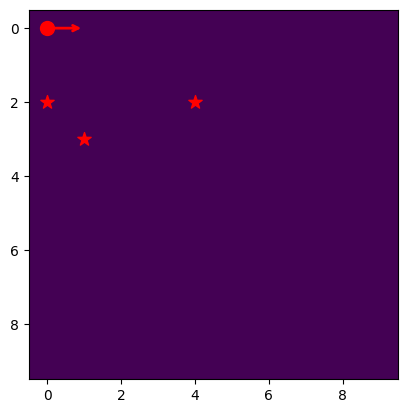

In [5]:
#############################################
# EXECUTE MANY TIMES TO SEE THE EVOLUTION!! #
#############################################


# ----------- CONTROL V---------------

action = torch.multinomial(policy[state], 1)
current_state = state
new_state = step_function(state,action )
if new_state in terminal_states:
  V[state] = V[state]+ alpha *(rewards[new_state] - V[state] )
  state = initial_state
else:
  V[state] = V[state]+ alpha *(rewards[new_state] + discount_factor * V[new_state]- V[state] )
  state = new_state


# ----------- VIZ ---------------
fig,ax = plt.subplots(1,1)

current_row = current_state // size
current_col = current_state % size
ax.scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
  ts_row = ts // size
  ts_col = ts % size
  ax.scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size


ax.annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = V.view(size,size)

ax.imshow(V_grid)

In [6]:
# ------------- ITERATIONS ---------------
for episode in range(episodes):
  for _ in range(max_step):
    action = torch.multinomial(policy[state], 1)
    new_state = step_function(state,action )
    if new_state in terminal_states:
      V[state] = V[state]+ alpha *(rewards[new_state] - V[state] )
      state = initial_state
    else:
      V[state] = V[state]+ alpha *(rewards[new_state] + discount_factor * V[new_state]- V[state] )
      state = new_state
# NOW RERUN THE CELL ABOVE

# SARSA - ON POLICY

In [7]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24,20,31]
size= 10
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.6

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

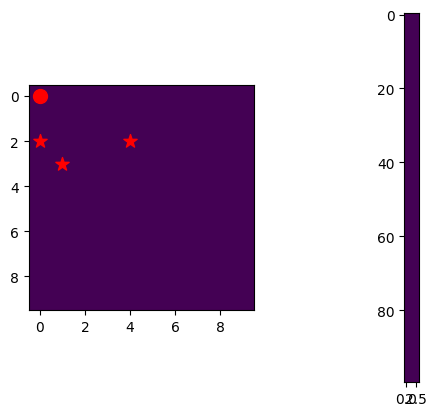

In [8]:
# ----------- CONTROL Q ---------------

action = torch.multinomial(policy[state], 1)
current_state = state
new_state = step_function(state,action )
new_action = torch.multinomial(policy[new_state], 1)
if new_state in terminal_states:
  Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
  state = initial_state
  action = new_action
else:
  Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action] )
  state = new_state
  action = new_action


# ----------- VIZ ---------------
fig,ax = plt.subplots(1,2)

current_row = current_state // size
current_col = current_state % size
ax[0].scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
  ts_row = ts // size
  ts_col = ts % size
  ax[0].scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size


ax[0].annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = Q.max(dim=1)[0].view(size, size)

ax[0].imshow(V_grid)
ax[1].imshow(policy)

In [9]:
# ------------- ITERATIONS ---------------
action = torch.multinomial(policy[state], 1)
for episode in range(episodes):
  for _ in range(max_step):
    new_state = step_function(state,action )
    new_action = torch.multinomial(policy[new_state], 1)
    if new_state in terminal_states:
      Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
      state = initial_state
      action = torch.multinomial(policy[state], 1)
    else:
      Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action] )
      state = new_state
      action = new_action
# NOW RERUN THE CELL ABOVE

## POLICY IMPROVEMENT

In [10]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24]
size= 5
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.4
epsilon = 0.1

policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([-0.1 if _ not in terminal_states else 2 for _ in range(states)])
# rewards[2] = -10
# rewards[6] = -10


state = initial_state
rewards

tensor([-0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
         2.0000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.10

In [11]:
def policy_improvement(Q, epsilon = 0.1):
    num_states, num_actions = Q.shape
    new_policy = torch.zeros(num_states, num_actions)

    for s in range(num_states):
        best_action = Q[s].argmax(0).item()

        for a in range(num_actions):
            if a == best_action:
                new_policy[s, a] = 1.0 - epsilon + (epsilon / num_actions)
            else:
                new_policy[s, a] = epsilon / num_actions
    return new_policy

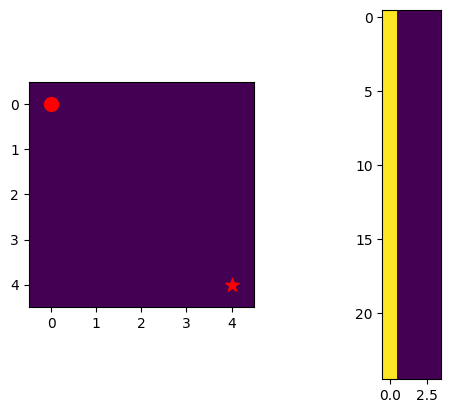

In [12]:
# ----------- CONTROL Q ---------------

action = torch.multinomial(policy[state], 1)
current_state = state

new_state = step_function(state,action)
new_action = torch.multinomial(policy[new_state], 1)

if new_state in terminal_states:
  Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
  state = initial_state
  action = new_action

else:
  Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action])
  state = new_state
  action = new_action


# ----------- IMPROVA POLICY ---------------
policy = policy_improvement(Q, epsilon=epsilon)


# ----------- VIZ ---------------
fig,ax = plt.subplots(1,2)

current_row = current_state // size
current_col = current_state % size
ax[0].scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
  ts_row = ts // size
  ts_col = ts % size
  ax[0].scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size


ax[0].annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = Q.max(dim=1)[0].view(size, size)

ax[0].imshow(V_grid)
ax[1].imshow(policy)

In [13]:
# ------------- ITERATIONS ---------------
action = torch.multinomial(policy[state], 1)
for episode in range(episodes):
  for _ in range(max_step):
    new_state = step_function(state,action )
    new_action = torch.multinomial(policy[new_state], 1)
    if new_state in terminal_states:
      Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
      state = initial_state
      action = torch.multinomial(policy[state], 1)
    else:
      Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action] )
      state = new_state
      action = new_action



# policy can be update here but also above, infact if we take it away from here and just run the cell above right after
# this cell, we obtain the same result
policy = policy_improvement(Q, epsilon=epsilon)
# NOW RERUN THE CELL ABOVE

# Q-Learning - OFF POLICY

In [14]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24,20,31]
size= 10
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.6

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

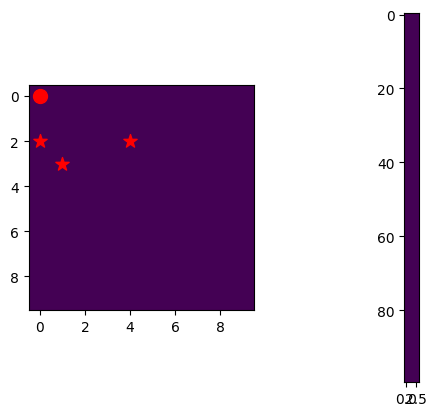

In [15]:
# ----------- CONTROL Q ---------------

action = torch.multinomial(policy[state], 1)
current_state = state
new_state = step_function(state,action )
new_action = torch.multinomial(policy[new_state], 1)
if new_state in terminal_states:
  Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
  state = initial_state
  action = new_action
else:
  Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state].max() - Q[state, action] )
  # THIS IS THE ONLY THING THAT CHANGES
  # infact here we are FOLLOWING THE EPSILON GREEDY POLICY (*) but then we are updating the action values using the policy that maximises the action values
  state = new_state
  action = new_action

# ----------- VIZ ---------------
fig,ax = plt.subplots(1,2)

current_row = current_state // size
current_col = current_state % size
ax[0].scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
  ts_row = ts // size
  ts_col = ts % size
  ax[0].scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size


ax[0].annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = Q.max(dim=1)[0].view(size, size)

ax[0].imshow(V_grid)
ax[1].imshow(policy)


In [16]:
# ------------- ITERATIONS ---------------
action = torch.multinomial(policy[state], 1)
for episode in range(episodes):
  for _ in range(max_step):
    new_state = step_function(state,action )
    new_action = torch.multinomial(policy[new_state], 1)
    if new_state in terminal_states:
      Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
      state = initial_state
      action = torch.multinomial(policy[state], 1)
    else:
      Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state].max()- Q[state, action] )
      state = new_state
      action = new_action

# NOW RERUN THE CELL ABOVE

## POLICY IMPROVEMENT

In [17]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24]
size= 5
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.4
epsilon = 0.1

policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([-0.1 if _ not in terminal_states else 2 for _ in range(states)])
# rewards[2] = -10
# rewards[6] = -10


state = initial_state
rewards

tensor([-0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
         2.0000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000, -0.1000,
        -0.1000, -0.1000, -0.1000, -0.10

In [18]:
def policy_improvement(Q, epsilon = 0.1):
    num_states, num_actions = Q.shape
    new_policy = torch.zeros(num_states, num_actions)

    for s in range(num_states):
        best_action = Q[s].argmax(0).item()

        for a in range(num_actions):
            if a == best_action:
                new_policy[s, a] = 1.0 - epsilon + (epsilon / num_actions)
            else:
                new_policy[s, a] = epsilon / num_actions
    return new_policy

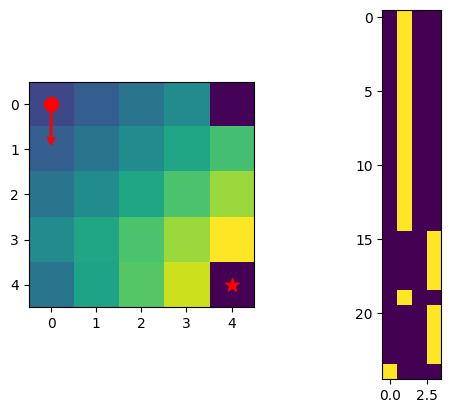

In [50]:
# ----------- CONTROL Q ---------------

action = torch.multinomial(policy[state], 1) # (*)
current_state = state

new_state = step_function(state,action)
new_action = torch.multinomial(policy[new_state], 1)

if new_state in terminal_states:
  Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
  state = initial_state
  action = new_action

else:
  Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state].max()- Q[state, action])
  # THIS IS THE ONLY THING THAT CHANGES
  # infact here we are FOLLOWING THE EPSILON GREEDY POLICY (*) but then we are updating the action values using the policy that maximises the action values

  state = new_state
  action = new_action


# ----------- IMPROVA POLICY ---------------
policy = policy_improvement(Q, epsilon=epsilon)


# ----------- VIZ ---------------
fig,ax = plt.subplots(1,2)

current_row = current_state // size
current_col = current_state % size
ax[0].scatter(current_col, current_row, c='red', s=100, marker='o')

for ts in terminal_states:
  ts_row = ts // size
  ts_col = ts % size
  ax[0].scatter(ts_col, ts_row, c='red', s=100, marker='*')

next_row = new_state // size
next_col = new_state % size


ax[0].annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = Q.max(dim=1)[0].view(size, size)

ax[0].imshow(V_grid)
ax[1].imshow(policy)

In [37]:
# ------------- ITERATIONS ---------------
action = torch.multinomial(policy[state], 1)
for episode in range(episodes):
  for _ in range(max_step):
    new_state = step_function(state,action )
    new_action = torch.multinomial(policy[new_state], 1)
    if new_state in terminal_states:
      Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
      state = initial_state
      action = torch.multinomial(policy[state], 1)
    else:
      Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state].max()- Q[state, action] )
      # THIS IS THE ONLY THING THAT CHANGES
      # infact here we are FOLLOWING THE EPSILON GREEDY POLICY (*) but then we are updating the action values using the policy that maximises the action values

      state = new_state
      action = new_action



# policy can be update here but also above, infact if we take it away from here and just run the cell above right after
# this cell, we obtain the same result
policy = policy_improvement(Q, epsilon=epsilon)
# NOW RERUN THE CELL ABOVE

# CONCLUSIONS
## Policy Updates in SARSA and Q-Learning

Both SARSA and Q-learning change the policy as they learn. The policy tells us which action to take in each state, and when we update the action values (Q-values), we can also update the policy.

## How We Update the Policy

In both algorithms, we update the policy by making the action that maximizes Q-values in each state the most likely choice. Specifically, we set the best action's probability to 1 minus something small (to account for epsilon and maintain exploration).

## Flexibility in Update Frequency

We have flexibility in how often we update the policy. We can update Q-values many times without updating the policy table. Then, at the end when we've learned good Q-values, we can update the policy once based on those final Q-values.

This works because the Q-values contain all the learned knowledge, and the policy is just a way to use those Q-values to select actions.

# Multiple Policy Learning
Summary: Learning Multiple Goals with Off-Policy Methods
Off-policy methods (Q-learning, Expected SARSA) can learn about multiple goals simultaneously from a single stream of experience.
How it works:
You follow one exploratory behavior policy (like ε-greedy) to collect experience. From that same experience, you can update multiple Q-tables, each with different reward functions corresponding to different goals.
Example:
A robot explores an environment once. From that single exploration episode, it simultaneously learns:

How to reach goal location A
How to reach goal location B
How to reach goal location C
How to navigate energy-efficiently

Each uses the same transitions but different rewards.
Why this is powerful:
One episode of experience teaches you about many different objectives. This is extremely data-efficient. You can even learn from "failures" - an episode that fails to reach goal A might successfully teach you about reaching goal B.
Why off-policy is needed:
Q-learning and Expected SARSA separate behavior (how you explore) from evaluation (what you learn). The max operation in Q-learning or the expectation in Expected SARSA doesn't depend on which specific goal you're pursuing.
SARSA can't do this as naturally because it's on-policy - it learns values for the specific exploratory policy you're following, which is tied to one goal at a time.
The key insight: Off-policy learning means you can learn about optimal behavior for multiple different tasks while exploring in just one way.Retry